# MPC of the diff drive robot test

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from adam.casadi.computations import KinDynComputations
import casadi as cs
from time import time as clock
from time import sleep
from termcolor import colored
from matplotlib.patches import Rectangle
from ipywidgets import interact, FloatSlider
import conf_limo as limo


### MPC initialization



Simple diff drive robot dynamics:
$$ \dot{x} = v \cos(\theta)$$
$$ \dot{y} = v \sin(\theta)$$
$$ \dot{\theta} = \omega $$

In [62]:
# states and inputs size
nx = 3 # size of state vector x = [x,y,theta]
nu = 2 # size of control vector u = [v, w]

# MPC settings
SOLVER_MAX_ITER = 5
SOLVER_TOLERANCE = 1e-4
dt_MPC = 0.010 # time step MPC
N = 10  # time horizon MPC
N_sim = 1000 # number of total simulation steps

# simulation settings
dt_sim = 0.002

# create the dynamics function
x = cs.SX.sym('x', nx)
u = cs.SX.sym('u', nu)
# defining the dynamics
rhs    = cs.vertcat(cs.cos(x[-1])*u[0],
                    cs.sin(x[-1])*u[0],
                    u[1])
f = cs.Function('f', [x, u], [rhs])

x_init = np.zeros(nx)              # initial state
u_min = [limo.v_min, limo.w_min]   # minimum value of u
u_max = [limo.v_max, limo.w_max]   # maximum value of u
robot_ray = limo.r_collision       # ray of the robot used for visualization

# desired position
x_des = [0.5,0.5,1.5]

# OCP weigths
w_v = 1e-2 # velocity weight
w_final_v = 1e-2 # final velocity cost weight

### MPC definition

In [63]:
def create_OCP_problem(u_min, u_max, w_v, w_final_v, N, dt):
    opti = cs.Opti()
    param_x_init = opti.parameter(nx)
    param_x_des = opti.parameter(nx)

    # Create all decision variables for state and control
    X, U = [], []
    for k in range(N+1): 
        X += [opti.variable(nx)]
    for k in range(N): 
        U += [opti.variable(nu)]
        opti.subject_to(opti.bounded(u_min, U[-1], u_max))

    # Add initial conditions
    opti.subject_to(X[0] == param_x_init)

    # Add cost function and dynamics constraints
    cost = 0
    for k in range(N):
        # control penality  
        cost += w_v * U[k].T @ U[k]
        # dynamics contraint
        opti.subject_to(X[k+1] == X[k] + dt * f(X[k], U[k]))

    # Terminal cost
    cost += (X[-1] - param_x_des).T @ (X[-1] - param_x_des)
    # Final velocity cost
    #cost += w_final_v * X[-1].T @ X[-1]

    opti.minimize(cost)

    # create the optimization solver
    opts = {
        "error_on_fail": False,
        "ipopt.print_level": 0,
        "ipopt.tol": SOLVER_TOLERANCE,
        "ipopt.constr_viol_tol": SOLVER_TOLERANCE,
        "ipopt.compl_inf_tol": SOLVER_TOLERANCE,
        "print_time": 0,                # print information about execution time
        "detect_simple_bounds": True,
        "ipopt.max_iter": 1000 # only for the warm start
    }
    opti.solver("ipopt", opts)
    
    return opti, X, U, param_x_init, param_x_des, opts

### MPC warm start

In [64]:
# warm starting the solver to 
def warm_start(opti, param_x_init, param_x_des):
    # Solve the problem to convergence the first time
    opti.set_value(param_x_des, x_des)
    opti.set_value(param_x_init, x_init)
    sol = opti.solve()
    return sol

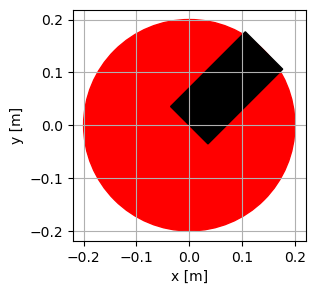

In [65]:
def plot_robot(x, ray, color1='r', color2='k', fill=1, axis=None):
    # x: 3d vector containing x, y and theta of the robot
    # ray: length of the ray of the robot
    # color1: color for the circle
    # color2: color for the rectangle
    # fill: if 1 the circle is filled with the color
    px, py, theta = x[0], x[1], x[2]
    if(axis is None):
        axis = plt.gca()
    axis.add_patch(plt.Circle((px, py), ray, color=color1, fill=fill))
    axis.add_patch(Rectangle((px, py-0.25*ray), ray, 0.5*ray, 
                              angle=theta*180/np.pi, rotation_point=(px, py), 
                             fill=1, color=color2))
    plt.grid(True)
    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    axis.axis('equal')

plt.figure(figsize=(3, 3))
plot_robot([0, 0, np.pi/4], robot_ray) # show the robot with an angle theta=pi/4

### Simulation

In [ ]:
def MPC_simulation():
    # initializing the vectors for solution plotting
    x_sol = np.zeros((nx,N_sim))
    u_sol = np.zeros((nu,N_sim))

    # initializing the MPC
    opti, X, U, param_x_init, param_x_des, opts = create_OCP_problem(u_min, u_max, w_v, w_final_v, N, dt_MPC)
    # warm start
    sol = warm_start(opti, param_x_init, param_x_des)
    
    # setting the max iter to the lower number for all other optimizations
    opts["ipopt.max_iter"] = SOLVER_MAX_ITER
    opti.solver("ipopt", opts)

    x = np.array(x_init)

    # STARTING THE MPC LOOP
    for i in range(N_sim):
        # use current solution as initial guess for next problem
        for t in range(N):
            # the values are shifted by 1 timestep
            opti.set_initial(X[t], sol.value(X[t+1]))
        for t in range(N-1):
            opti.set_initial(U[t], sol.value(U[t+1]))
        # last value since it is missing is taken as the last value of the previous simulation
        opti.set_initial(X[N], sol.value(X[N]))
        opti.set_initial(U[N-1], sol.value(U[N-1]))

        # use the same lagrange multiplier in the next simulation
        lam_g0 = sol.value(opti.lam_g)
        opti.set_initial(opti.lam_g, lam_g0)
        
        print("Time step", i, "State", x, "Input", sol.value(U[0]))
        opti.set_value(param_x_init, x)
        try:
            sol = opti.solve()
        except:
            sol = opti.debug

        # updating the states value (feedback from kalman filter)
        x = sol.value(X[1])

        # saving the results for plotting
        x_sol[:,i] = sol.value(X[0])
        u_sol[:,i] = sol.value(U[0])

    plt.figure(figsize=(10, 4))
    plot_robot((x_des[0], x_des[1], x_des[2]), robot_ray)
    plt.plot(x_sol[0,:], x_sol[1,:].T, 'x-', label='x', alpha=0.7)
    for k in range(1,N_sim):
        plot_robot(x_sol[:,k], robot_ray, 'k', fill=0)
    plot_robot(x_init, robot_ray, 'b')
    plt.legend()
    plt.show()

### Result plot

Time step 0 State [0. 0. 0.] Input [0.45140424 1.38292277]
Time step 1 State [0.00451405 0.         0.01382924] Input [0.45140465 1.38292393]
Time step 2 State [9.04953483e-03 6.27263518e-05 2.75305469e-02] Input [0.4535922  1.37013076]
Time step 3 State [0.01360401 0.00018815 0.04110503] Input [0.45562058 1.3574484 ]
Time step 4 State [0.01817504 0.00037614 0.05455379] Input [0.45748883 1.34487617]
Time step 5 State [0.02276022 0.00062653 0.06787793] Input [0.45920093 1.33241354]
Time step 6 State [0.02735721 0.00093905 0.08107853] Input [0.4607608  1.32005998]
Time step 7 State [0.03196375 0.00131336 0.09415668] Input [0.46217233 1.30781494]
Time step 8 State [0.03657762 0.00174907 0.10711346] Input [0.46343935 1.29567786]
Time step 9 State [0.04119665 0.00224573 0.11994994] Input [0.46456564 1.28364816]
Time step 10 State [0.04581875 0.00280283 0.13266719] Input [0.46555494 1.27172527]
Time step 11 State [0.05044187 0.00341979 0.14526628] Input [0.46641093 1.25990858]
Time step 12 S

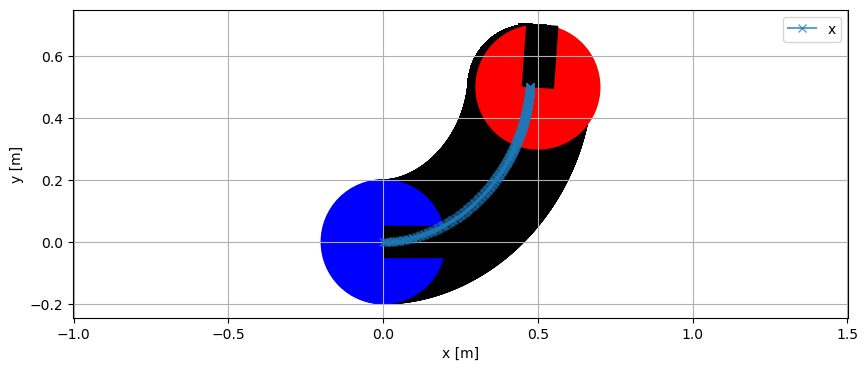

In [67]:
def plot_robot(x, ray, color1='r', color2='k', fill=1, axis=None):
    # x: 3d vector containing x, y and theta of the robot
    # ray: length of the ray of the robot
    # color1: color for the circle
    # color2: color for the rectangle
    # fill: if 1 the circle is filled with the color
    px, py, theta = x[0], x[1], x[2]
    if(axis is None):
        axis = plt.gca()
    axis.add_patch(plt.Circle((px, py), ray, color=color1, fill=fill))
    axis.add_patch(Rectangle((px, py-0.25*ray), ray, 0.5*ray, 
                              angle=theta*180/np.pi, rotation_point=(px, py), 
                             fill=1, color=color2))
    plt.grid(True)
    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    axis.axis('equal')

MPC_simulation()